In [29]:
import obspy
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

# Initialize FDSN client (e.g., IRIS, GEONET, BGR, etc.)
client = Client("EARTHSCOPE")

# Define the earthquake origin time (YYYY-MM-DDTHH:MM:SS)
# Example: The 2011 Tohoku Earthquake
t = UTCDateTime("2011-03-11T05:46:23")

print("Time object created successfully.")


Time object created successfully.


In [30]:
# Network, Station, Location, Channel 
# BHZ = Broadband, High Gain, Vertical Component
st = client.get_waveforms("II", "PFO", "00", "BHZ", t, t + 3600)

print(st)


1 Trace(s) in Stream:
II.PFO.00.BHZ | 2011-03-11T05:46:23.019500Z - 2011-03-11T06:46:22.969500Z | 20.0 Hz, 72000 samples


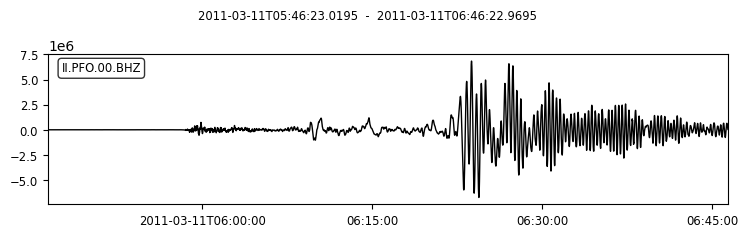

In [31]:
# Basic plot of all traces in the stream
st.plot()
print()


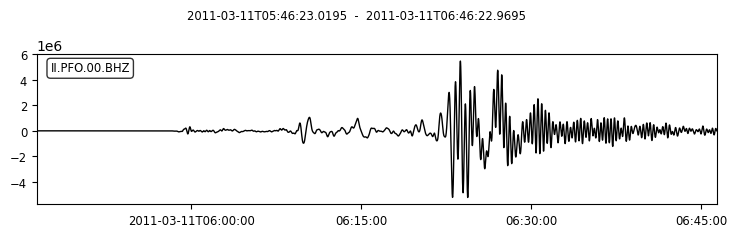

In [32]:
# Create a copy so we don't alter the raw data
st_processed = st.copy()

# Detrend to remove any baseline shifts
st_processed.detrend("linear")

# Apply a lowpass filter (e.g., corner frequency of 0.05 Hz)
st_processed.filter("lowpass", freq=0.05, corners=2, zerophase=True)

# Plot the processed seismogram
st_processed.plot()
print()

In [35]:
client = Client("USGS")

# 1. Fetch the Tohoku earthquake event details
t = UTCDateTime("2011-03-11T05:46:23")
catalog = client.get_events(starttime=t-60, endtime=t+60, minmagnitude=8.5)

client = Client("EARTHSCOPE")
# 2. Fetch the station inventory
inventory = client.get_stations(network="II", station="PFO", location="00", level="station")

print(catalog)
print(inventory)


1 Event(s) in Catalog:
2011-03-11T05:46:24.120000Z | +38.297, +142.373 | 9.1  mww | manual
Inventory created at 2026-07-19T17:46:40.603500Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?network=II&st...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			II
		Stations (3):
			II.PFO (Pinon Flat, California, USA) (3x)
		Channels (0):



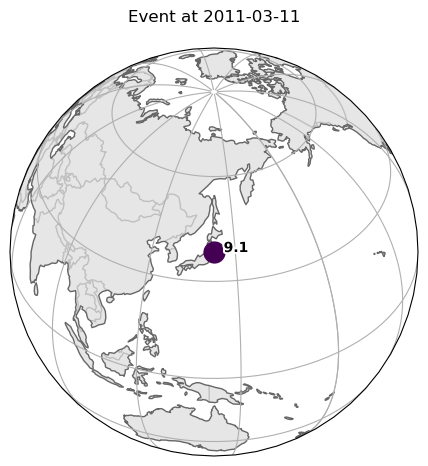

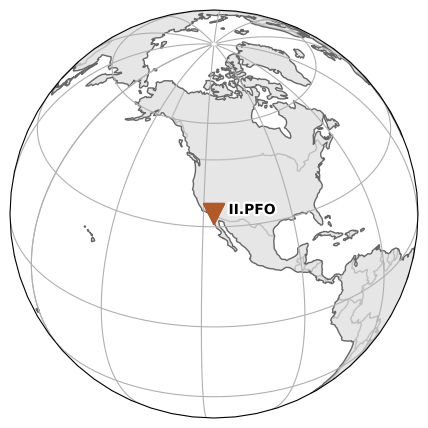

In [36]:
# Plot the earthquake location globally
catalog.plot(projection="ortho")
print()

# Plot the station location globally
inventory.plot(projection="ortho")
print()


In [ ]:
client = Client("USGS")

# 1. Fetch the Tohoku earthquake event details
t = UTCDateTime("2011-03-11T05:46:23")
fullcatalog = client.get_events(starttime=t-86400*7, endtime=t+86400*7, minmagnitude=4)

print(fullcatalog)
